In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [4]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:")
print(cv_scores)

print("\nMean ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation ROC-AUC scores:
[0.84776954 0.8251438  0.84191266 0.86276518 0.85304502]

Mean ROC-AUC: 0.846127236084446
Standard Deviation: 0.012533485282643853


In [10]:
balanced_logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [11]:
balanced_logistic.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [12]:
y_pred_balanced = balanced_logistic.predict(X_test)
y_prob_balanced = balanced_logistic.predict_proba(X_test)[:, 1]

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

Accuracy: 0.7381121362668559
Precision: 0.504302925989673
Recall: 0.7834224598930482
F1 Score: 0.6136125654450262
ROC-AUC: 0.8416905629181844


In [14]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1035
        True       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [19]:
rf = RandomForestClassifier(
    random_state=42
)

In [16]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [20]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [21]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [22]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-validation ROC-AUC:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}

Best Cross-validation ROC-AUC:
0.8453907400670474


In [23]:
best_rf = rf_search.best_estimator_

In [24]:
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

Accuracy: 0.8005677785663591
Precision: 0.6654804270462633
Recall: 0.5
F1 Score: 0.5709923664122137
ROC-AUC: 0.8447944922369475


In [26]:
normal_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

normal_logistic.fit(X_train, y_train)

y_pred_normal = normal_logistic.predict(X_test)
y_prob_normal = normal_logistic.predict_proba(X_test)[:, 1]

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_normal),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_normal),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_normal),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_normal),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_normal),
        roc_auc_score(y_test, y_prob_balanced),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842006
1,Balanced Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841691
2,Tuned Random Forest,0.800568,0.665480,0.500000,0.570992,0.844794


In [28]:
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
1,Balanced Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8417
2,Tuned Random Forest,0.8006,0.6655,0.5000,0.5710,0.8448


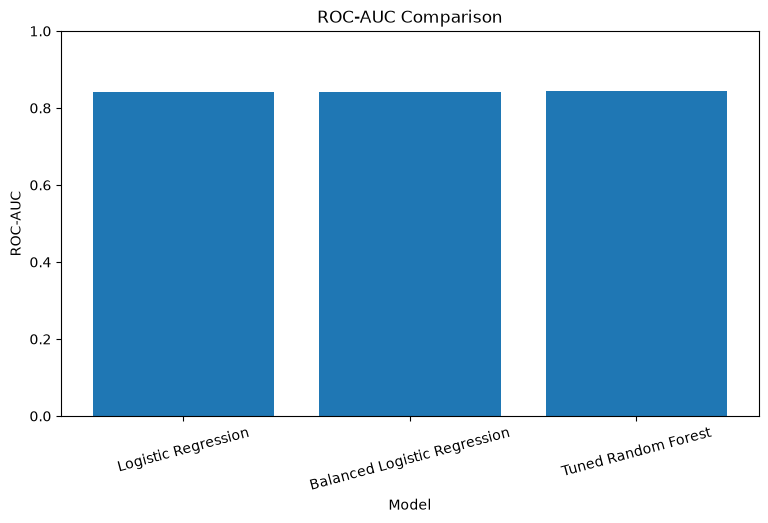

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [30]:
fpr_normal, tpr_normal, _ = roc_curve(y_test, y_prob_normal)

fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_prob_balanced)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)

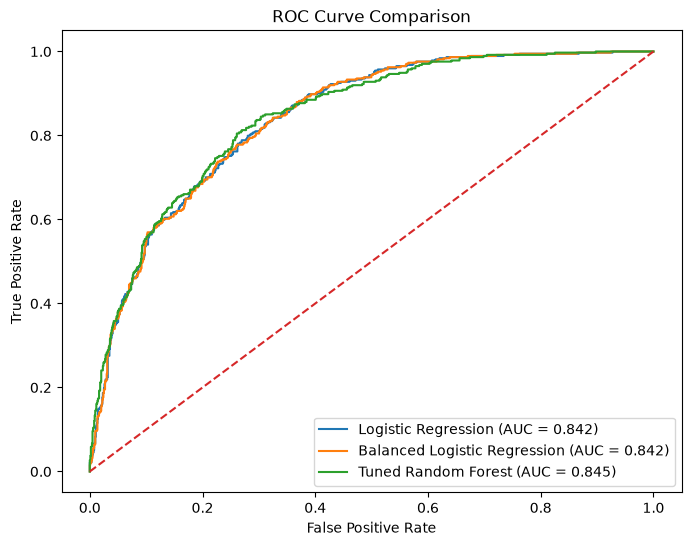

In [31]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_normal,
    tpr_normal,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_normal):.3f})"
)

plt.plot(
    fpr_balanced,
    tpr_balanced,
    label=f"Balanced Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_balanced):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Tuned Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf_tuned):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [32]:
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Tuned Random Forest,0.800568,0.665480,0.500000,0.570992,0.844794
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842006
1,Balanced Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841691


In [42]:
final_model = normal_logistic
final_model_name = "Logistic Regression"

In [43]:
print("Final Selected Model:", final_model_name)

Final Selected Model: Logistic Regression


In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": final_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
10,InternetService_Fiber optic,1.198969
3,TotalCharges,0.513307
21,StreamingTV_Yes,0.383166
23,StreamingMovies_Yes,0.382559
28,PaymentMethod_Electronic check,0.381118
26,PaperlessBilling_Yes,0.372901
9,MultipleLines_Yes,0.364684
29,PaymentMethod_Mailed check,0.072411
0,SeniorCitizen,0.054616
17,DeviceProtection_Yes,0.037949


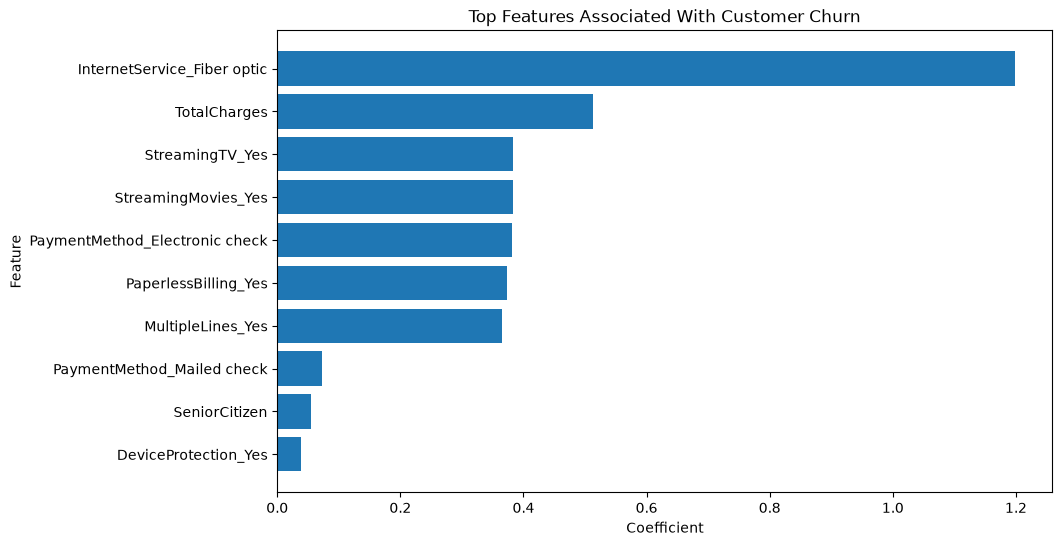

In [45]:
top_churn_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_churn_features["Feature"],
    top_churn_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated With Customer Churn")

plt.gca().invert_yaxis()

plt.show()